<a href="https://colab.research.google.com/github/maulsabani01-cell/Tugas-data-mining-2304020137/blob/main/Clustering_Pendidikan_SMA_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 K-Means Clustering
## Persentase Penduduk Usia 25 Tahun ke Atas dengan Pendidikan SMA ke Atas
### Menurut Jenis Kelamin per Provinsi — Indonesia 2025

---
**Alur analisis:**
1. Muat & eksplorasi data mentah
2. Filter data tingkat provinsi
3. Bersihkan & validasi data
4. Standardisasi fitur
5. Tentukan jumlah klaster optimal (Elbow + Silhouette)
6. Latih model K-Means
7. Visualisasi & interpretasi hasil

---
## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Gaya plot
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_palette('tab10')

print('✅ Semua library berhasil diimpor.')

✅ Semua library berhasil diimpor.


---
## 2. Muat & Eksplorasi Data Mentah

In [ ]:
from google.colab import files

print("Silakan upload file CSV Anda")
uploaded = files.upload()

FILE_PATH = list(uploaded.keys())[0]

print(f'File berhasil diupload: {FILE_PATH}')

with open(FILE_PATH, encoding='utf-8') as f:
    raw_text = f.read()

print('=== 8 Baris Pertama File Mentah ===')
for line in raw_text.split('\n')[:8]:
    print(repr(line))

Silakan upload file CSV Anda


Saving Persentase penduduk usia 25 Tahun keatas dengan pendidikan SMA ke atas menurut jenis kelamin, 2025 (1).csv to Persentase penduduk usia 25 Tahun keatas dengan pendidikan SMA ke atas menurut jenis kelamin, 2025 (1).csv
File berhasil diupload: Persentase penduduk usia 25 Tahun keatas dengan pendidikan SMA ke atas menurut jenis kelamin, 2025 (1).csv
=== 8 Baris Pertama File Mentah ===
'Provinsi/Kabupaten/Kota/Indonesia;"Persentase penduduk usia 25 Tahun keatas '
'dengan pendidikan SMA ke atas menurut jenis kelamin (Persen)";'
';;'
';Laki-laki;Perempuan'
';2025;2025'
'ACEH;53,12;49,76'
'Simeulue;54,42;44,7'
'Aceh Singkil;45,73;40,14'


---
## 3. Pembersihan & Filter Data Provinsi

In [ ]:
# ── Parse baris demi baris (separator: titik koma) ──
records = []
for line in raw_text.split('\n'):
    parts = line.split(';')
    if len(parts) >= 3:
        records.append([parts[0].strip(), parts[1].strip(), parts[2].strip()])

df_raw = pd.DataFrame(records, columns=['Wilayah', 'Laki_laki', 'Perempuan'])

print(f'Total baris data mentah : {len(df_raw)}')
print('\nContoh data mentah:')
df_raw.head(10)

Total baris data mentah : 583

Contoh data mentah:


,Wilayah,Laki_laki,Perempuan
0,,,
1,,Laki-laki,Perempuan
2,,2025,2025
3,ACEH,"53,12","49,76"
4,Simeulue,"54,42","44,7"
5,Aceh Singkil,"45,73","40,14"
6,Aceh Selatan,"45,35","41,59"
7,Aceh Tenggara,"64,53","51,79"
8,Aceh Timur,"36,65","33,31"
9,Aceh Tengah,"58,15","60,59"


In [ ]:
# ── Fungsi deteksi baris Provinsi ──
# Provinsi ditandai dengan nama KAPITAL SEMUA
# Contoh: ACEH, JAWA BARAT, D I YOGYAKARTA, KEP. BANGKA BELITUNG
def is_province(name: str) -> bool:
    name = name.strip()
    if not name or name == 'INDONESIA':   # hapus total nasional
        return False
    # Harus diawali huruf kapital & seluruh karakter huruf/angka/spasi/titik/slash
    return bool(re.match(r'^[A-Z][A-Z0-9\s\.\(\)\/]+$', name)) and len(name) > 3

# ── Filter provinsi ──
df_prov = df_raw[df_raw['Wilayah'].apply(is_province)].copy()
df_prov.reset_index(drop=True, inplace=True)

# ── Konversi nilai (koma → titik) ──
for col in ['Laki_laki', 'Perempuan']:
    df_prov[col] = df_prov[col].str.replace(',', '.', regex=False)

# ── Hapus baris dengan nilai '-' (data tidak tersedia) ──
df_prov = df_prov[
    (df_prov['Laki_laki'] != '-') & (df_prov['Perempuan'] != '-') &
    (df_prov['Laki_laki'] != '')  & (df_prov['Perempuan'] != '')
]

# ── Konversi ke numerik ──
df_prov['Laki_laki'] = pd.to_numeric(df_prov['Laki_laki'], errors='coerce')
df_prov['Perempuan'] = pd.to_numeric(df_prov['Perempuan'], errors='coerce')

# ── Hapus baris kosong/NaN tersisa ──
df_prov.dropna(inplace=True)
df_prov.reset_index(drop=True, inplace=True)

print(f'Jumlah provinsi setelah pembersihan: {len(df_prov)}')
print(f'Missing values  : {df_prov.isnull().sum().sum()}')
df_prov

Jumlah provinsi setelah pembersihan: 38
Missing values  : 0


,Wilayah,Laki_laki,Perempuan
0,ACEH,53.12,49.76
1,SUMATERA UTARA,55.64,52.01
2,SUMATERA BARAT,46.66,50.12
3,RIAU,46.88,44.22
4,JAMBI,42.25,36.77
5,SUMATERA SELATAN,41.70,36.93
6,BENGKULU,44.67,42.13
7,LAMPUNG,36.58,32.33
8,KEP. BANGKA BELITUNG,41.54,39.72
9,KEPULAUAN RIAU,65.40,60.08


---
## 4. Eksplorasi Data Provinsi (EDA)

In [ ]:
print('=== Statistik Deskriptif ===')
print(df_prov[['Laki_laki', 'Perempuan']].describe().round(2))

print('\n=== Provinsi dengan Persentase Tertinggi (Laki-laki) ===')
print(df_prov.nlargest(5, 'Laki_laki')[['Wilayah','Laki_laki','Perempuan']].to_string(index=False))

print('\n=== Provinsi dengan Persentase Terendah (Laki-laki) ===')
print(df_prov.nsmallest(5, 'Laki_laki')[['Wilayah','Laki_laki','Perempuan']].to_string(index=False))

=== Statistik Deskriptif ===
       Laki_laki  Perempuan
count      38.00      38.00
mean       46.01      41.30
std        10.64      10.44
min        21.00      12.32
25%        39.02      34.53
50%        44.74      40.13
75%        54.29      49.74
max        71.89      64.70

=== Provinsi dengan Persentase Tertinggi (Laki-laki) ===
         Wilayah  Laki_laki  Perempuan
     DKI JAKARTA      71.89      64.70
  KEPULAUAN RIAU      65.40      60.08
           PAPUA      63.01      55.73
PAPUA BARAT DAYA      62.26      55.35
KALIMANTAN TIMUR      57.95      49.68

=== Provinsi dengan Persentase Terendah (Laki-laki) ===
            Wilayah  Laki_laki  Perempuan
   PAPUA PEGUNUNGAN      21.00      12.32
       PAPUA TENGAH      31.08      26.68
          GORONTALO      31.37      37.47
        JAWA TENGAH      33.21      28.74
NUSA TENGGARA TIMUR      35.95      32.87


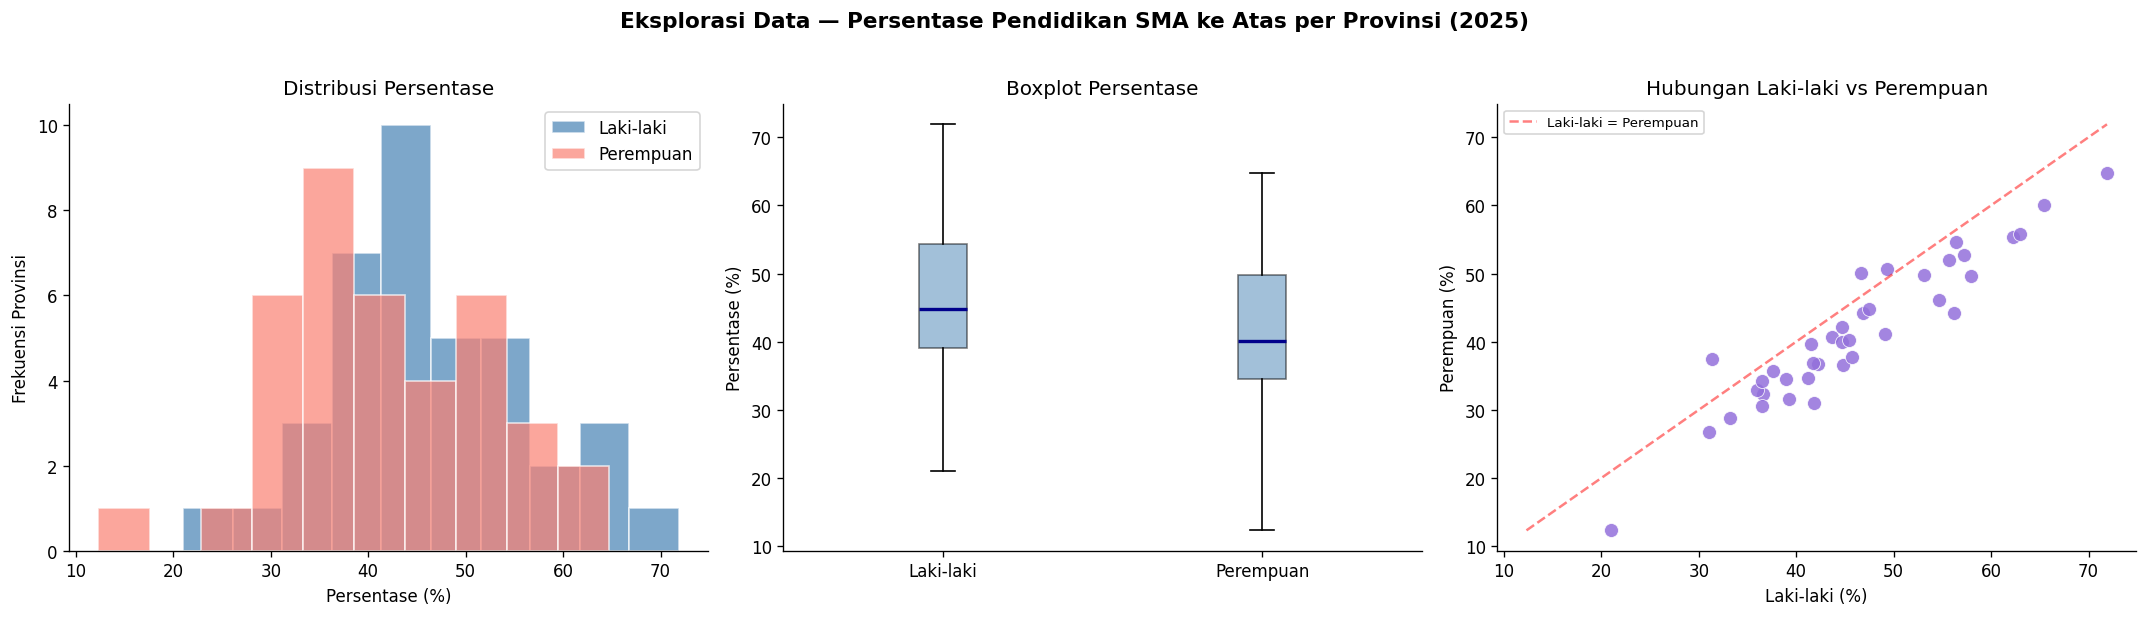

Gambar disimpan: eda_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Eksplorasi Data — Persentase Pendidikan SMA ke Atas per Provinsi (2025)',
             fontsize=13, fontweight='bold', y=1.02)

# Histogram
axes[0].hist(df_prov['Laki_laki'], bins=10, alpha=0.7, color='steelblue', edgecolor='white', label='Laki-laki')
axes[0].hist(df_prov['Perempuan'], bins=10, alpha=0.7, color='salmon',    edgecolor='white', label='Perempuan')
axes[0].set_title('Distribusi Persentase')
axes[0].set_xlabel('Persentase (%)')
axes[0].set_ylabel('Frekuensi Provinsi')
axes[0].legend()

# Boxplot
axes[1].boxplot([df_prov['Laki_laki'], df_prov['Perempuan']],
                labels=['Laki-laki', 'Perempuan'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='darkblue', linewidth=2))
axes[1].set_title('Boxplot Persentase')
axes[1].set_ylabel('Persentase (%)')

# Scatter
axes[2].scatter(df_prov['Laki_laki'], df_prov['Perempuan'], s=70,
                color='mediumpurple', edgecolors='white', linewidths=0.5, alpha=0.85)
axes[2].set_xlabel('Laki-laki (%)')
axes[2].set_ylabel('Perempuan (%)')
axes[2].set_title('Hubungan Laki-laki vs Perempuan')
# Garis diagonal y=x sebagai referensi kesetaraan
lim_min = min(df_prov[['Laki_laki','Perempuan']].min())
lim_max = max(df_prov[['Laki_laki','Perempuan']].max())
axes[2].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.5, label='Laki-laki = Perempuan')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan: eda_overview.png')

---
## 5. Standardisasi Data

In [ ]:
# Pilih fitur untuk clustering
features = ['Laki_laki', 'Perempuan']
X = df_prov[features].values

# StandardScaler → mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=[f'{c}_scaled' for c in features])

print('=== Sebelum Standardisasi ===')
print(pd.DataFrame(X, columns=features).describe().round(2))

print('\n=== Setelah Standardisasi ===')
print(df_scaled.describe().round(4))

=== Sebelum Standardisasi ===
       Laki_laki  Perempuan
count      38.00      38.00
mean       46.01      41.30
std        10.64      10.44
min        21.00      12.32
25%        39.02      34.53
50%        44.74      40.13
75%        54.29      49.74
max        71.89      64.70

=== Setelah Standardisasi ===
       Laki_laki_scaled  Perempuan_scaled
count           38.0000           38.0000
mean            -0.0000            0.0000
std              1.0134            1.0134
min             -2.3822           -2.8141
25%             -0.6660           -0.6576
50%             -0.1217           -0.1138
75%              0.7883            0.8193
max              2.4645            2.2719


---
## 6. Menentukan Jumlah Klaster Optimal
### Metode: Elbow (WCSS) + Silhouette Score + Davies-Bouldin Index

In [ ]:
K_range   = range(2, 9)
wcss      = []
sil_scores = []
db_scores  = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Ringkasan
results_df = pd.DataFrame({
    'K'         : list(K_range),
    'WCSS'      : wcss,
    'Silhouette': sil_scores,
    'Davies-Bouldin': db_scores
})
print(results_df.round(4).to_string(index=False))

 K    WCSS  Silhouette  Davies-Bouldin
 2 27.2717      0.5641          0.5633
 3 17.0497      0.4434          0.6625
 4 11.1694      0.4356          0.5341
 5  6.3717      0.4683          0.5201
 6  5.2527      0.4083          0.6213
 7  4.2819      0.4090          0.5888
 8  3.3960      0.3978          0.5348


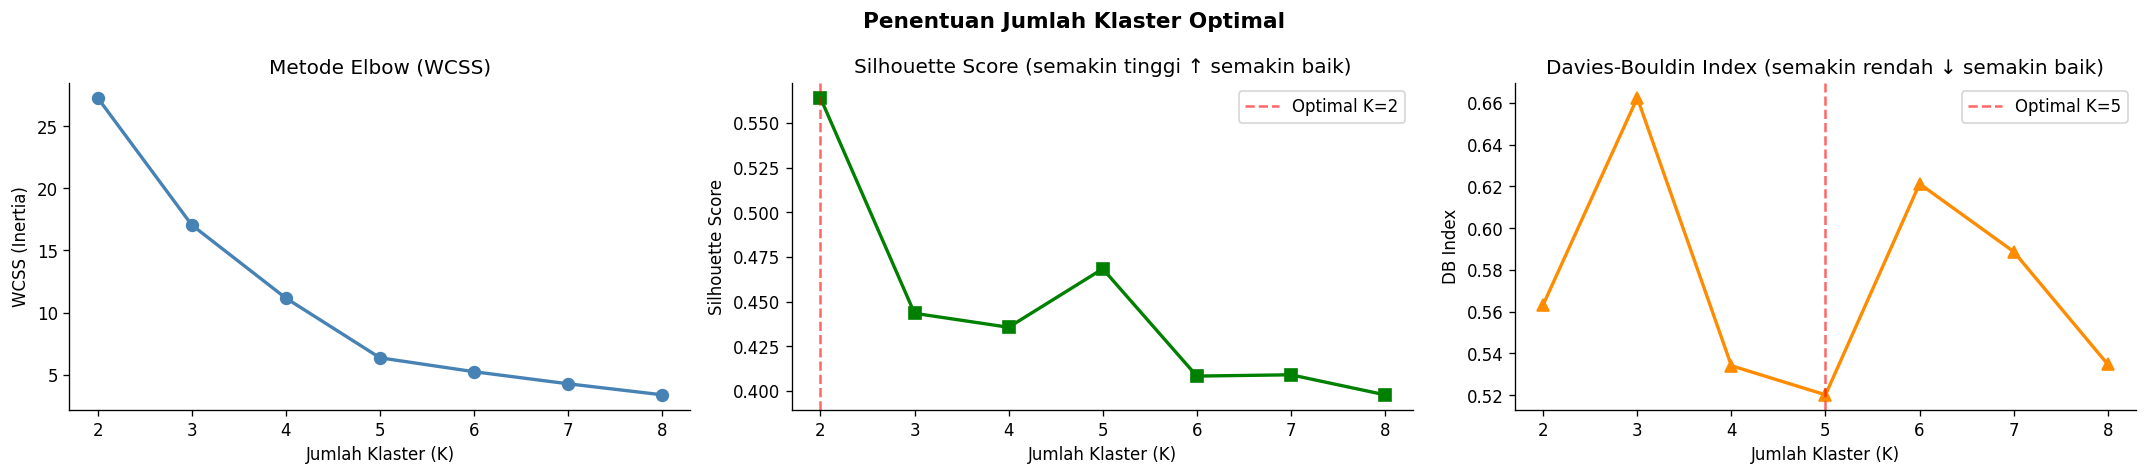


▶ Silhouette terbaik pada K = 2  (score = 0.5641)
▶ Davies-Bouldin terbaik pada K = 5  (score = 0.5201)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Penentuan Jumlah Klaster Optimal', fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(K_range, wcss, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Metode Elbow (WCSS)')
axes[0].set_xlabel('Jumlah Klaster (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_xticks(list(K_range))

# Silhouette
best_k_sil = list(K_range)[np.argmax(sil_scores)]
axes[1].plot(K_range, sil_scores, 's-', color='green', linewidth=2, markersize=7)
axes[1].axvline(x=best_k_sil, linestyle='--', color='red', alpha=0.6,
                label=f'Optimal K={best_k_sil}')
axes[1].set_title('Silhouette Score (semakin tinggi ↑ semakin baik)')
axes[1].set_xlabel('Jumlah Klaster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()

# Davies-Bouldin
best_k_db = list(K_range)[np.argmin(db_scores)]
axes[2].plot(K_range, db_scores, '^-', color='darkorange', linewidth=2, markersize=7)
axes[2].axvline(x=best_k_db, linestyle='--', color='red', alpha=0.6,
                label=f'Optimal K={best_k_db}')
axes[2].set_title('Davies-Bouldin Index (semakin rendah ↓ semakin baik)')
axes[2].set_xlabel('Jumlah Klaster (K)')
axes[2].set_ylabel('DB Index')
axes[2].set_xticks(list(K_range))
axes[2].legend()

plt.tight_layout()
plt.savefig('optimal_k.png', bbox_inches='tight')
plt.show()

print(f'\n▶ Silhouette terbaik pada K = {best_k_sil}  (score = {max(sil_scores):.4f})')
print(f'▶ Davies-Bouldin terbaik pada K = {best_k_db}  (score = {min(db_scores):.4f})')

---
## 7. Pemodelan K-Means Clustering

In [ ]:
# ── Tetapkan jumlah klaster (sesuaikan berdasarkan hasil grafik di atas) ──
OPTIMAL_K = 3   # ← Ganti jika hasil grafik menunjukkan K lain

kmeans = KMeans(
    n_clusters  = OPTIMAL_K,
    init        = 'k-means++',  # inisialisasi cerdas
    n_init      = 20,           # 20 kali percobaan random
    max_iter    = 300,
    random_state= 42
)

df_prov['Klaster'] = kmeans.fit_predict(X_scaled)

# Evaluasi
sil_final = silhouette_score(X_scaled, df_prov['Klaster'])
db_final  = davies_bouldin_score(X_scaled, df_prov['Klaster'])
inertia   = kmeans.inertia_

print(f'=== Evaluasi Model K-Means (K={OPTIMAL_K}) ===')
print(f'Silhouette Score   : {sil_final:.4f}  (mendekati 1 = klaster terpisah baik)')
print(f'Davies-Bouldin     : {db_final:.4f}   (mendekati 0 = klaster kompak & terpisah)')
print(f'Inertia (WCSS)     : {inertia:.4f}')

=== Evaluasi Model K-Means (K=3) ===
Silhouette Score   : 0.4434  (mendekati 1 = klaster terpisah baik)
Davies-Bouldin     : 0.6625   (mendekati 0 = klaster kompak & terpisah)
Inertia (WCSS)     : 17.0497


In [ ]:
# Pusat klaster dalam skala asli
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.index.name = 'Klaster'

print('=== Pusat Klaster (Skala Asli - %) ===')
print(centers_df.round(2))

# Statistik per klaster
print('\n=== Statistik Rata-rata per Klaster ===')
cluster_stats = df_prov.groupby('Klaster')[features].agg(['mean','min','max','count']).round(2)
cluster_stats.columns = ['_'.join(c) for c in cluster_stats.columns]
print(cluster_stats.to_string())

=== Pusat Klaster (Skala Asli - %) ===
         Laki_laki  Perempuan
Klaster                      
0            58.58      52.96
1            34.98      30.67
2            44.70      40.42

=== Statistik Rata-rata per Klaster ===
         Laki_laki_mean  Laki_laki_min  Laki_laki_max  Laki_laki_count  Perempuan_mean  Perempuan_min  Perempuan_max  Perempuan_count
Klaster                                                                                                                              
0                 58.58          49.27          71.89               12           52.96          44.27          64.70               12
1                 34.98          21.00          41.80               12           30.67          12.32          37.47               12
2                 44.70          41.20          49.15               14           40.42          34.71          50.12               14


---
## 8. Pelabelan & Interpretasi Klaster

In [ ]:
# Urutkan klaster berdasarkan rata-rata Laki_laki (rendah → tinggi)
cluster_means = df_prov.groupby('Klaster')['Laki_laki'].mean().sort_values()
rank_map = {old_k: new_k for new_k, old_k in enumerate(cluster_means.index)}
df_prov['Klaster'] = df_prov['Klaster'].map(rank_map)

# Label deskriptif
label_map = {
    0: 'Klaster 0 — Pendidikan Rendah',
    1: 'Klaster 1 — Pendidikan Menengah',
    2: 'Klaster 2 — Pendidikan Tinggi',
    # Jika K=4 atau lebih, tambahkan label di sini
    3: 'Klaster 3 — Pendidikan Sangat Tinggi',
    4: 'Klaster 4 — Pendidikan Sangat Rendah',
}
df_prov['Label_Klaster'] = df_prov['Klaster'].map(
    {k: v for k, v in label_map.items() if k < OPTIMAL_K}
)

# Tampilkan hasil
print('=== Hasil Clustering per Provinsi ===')
display_cols = ['Wilayah', 'Laki_laki', 'Perempuan', 'Klaster', 'Label_Klaster']
print(df_prov[display_cols].sort_values(['Klaster', 'Wilayah']).to_string(index=False))

=== Hasil Clustering per Provinsi ===
             Wilayah  Laki_laki  Perempuan  Klaster                   Label_Klaster
           GORONTALO      31.37      37.47        0   Klaster 0 — Pendidikan Rendah
         JAWA TENGAH      33.21      28.74        0   Klaster 0 — Pendidikan Rendah
          JAWA TIMUR      39.26      31.58        0   Klaster 0 — Pendidikan Rendah
    KALIMANTAN BARAT      36.45      30.61        0   Klaster 0 — Pendidikan Rendah
   KALIMANTAN TENGAH      38.94      34.47        0   Klaster 0 — Pendidikan Rendah
             LAMPUNG      36.58      32.33        0   Klaster 0 — Pendidikan Rendah
 NUSA TENGGARA BARAT      41.80      30.96        0   Klaster 0 — Pendidikan Rendah
 NUSA TENGGARA TIMUR      35.95      32.87        0   Klaster 0 — Pendidikan Rendah
    PAPUA PEGUNUNGAN      21.00      12.32        0   Klaster 0 — Pendidikan Rendah
        PAPUA TENGAH      31.08      26.68        0   Klaster 0 — Pendidikan Rendah
      SULAWESI BARAT      36.44      3

In [ ]:
print('=== Anggota Tiap Klaster ===')
for k in range(OPTIMAL_K):
    members = df_prov[df_prov['Klaster'] == k]
    label   = label_map.get(k, f'Klaster {k}')
    print(f'\n{'─'*55}')
    print(f'{label}  ({len(members)} provinsi)')
    print(f'  Laki-laki : {members["Laki_laki"].mean():.2f}%  '
          f'(min {members["Laki_laki"].min():.2f}% – max {members["Laki_laki"].max():.2f}%)')
    print(f'  Perempuan : {members["Perempuan"].mean():.2f}%  '
          f'(min {members["Perempuan"].min():.2f}% – max {members["Perempuan"].max():.2f}%)')
    print('  Anggota   :', ', '.join(members['Wilayah'].tolist()))

=== Anggota Tiap Klaster ===

───────────────────────────────────────────────────────
Klaster 0 — Pendidikan Rendah  (12 provinsi)
  Laki-laki : 34.98%  (min 21.00% – max 41.80%)
  Perempuan : 30.67%  (min 12.32% – max 37.47%)
  Anggota   : LAMPUNG, JAWA TENGAH, JAWA TIMUR, NUSA TENGGARA BARAT, NUSA TENGGARA TIMUR, KALIMANTAN BARAT, KALIMANTAN TENGAH, SULAWESI TENGAH, GORONTALO, SULAWESI BARAT, PAPUA TENGAH, PAPUA PEGUNUNGAN

───────────────────────────────────────────────────────
Klaster 1 — Pendidikan Menengah  (14 provinsi)
  Laki-laki : 44.70%  (min 41.20% – max 49.15%)
  Perempuan : 40.42%  (min 34.71% – max 50.12%)
  Anggota   : SUMATERA BARAT, RIAU, JAMBI, SUMATERA SELATAN, BENGKULU, KEP. BANGKA BELITUNG, JAWA BARAT, BANTEN, KALIMANTAN SELATAN, KALIMANTAN UTARA, SULAWESI SELATAN, SULAWESI TENGGARA, MALUKU UTARA, PAPUA SELATAN

───────────────────────────────────────────────────────
Klaster 2 — Pendidikan Tinggi  (12 provinsi)
  Laki-laki : 58.58%  (min 49.27% – max 71.89%)
  Per

---
## 9. Visualisasi Hasil Clustering

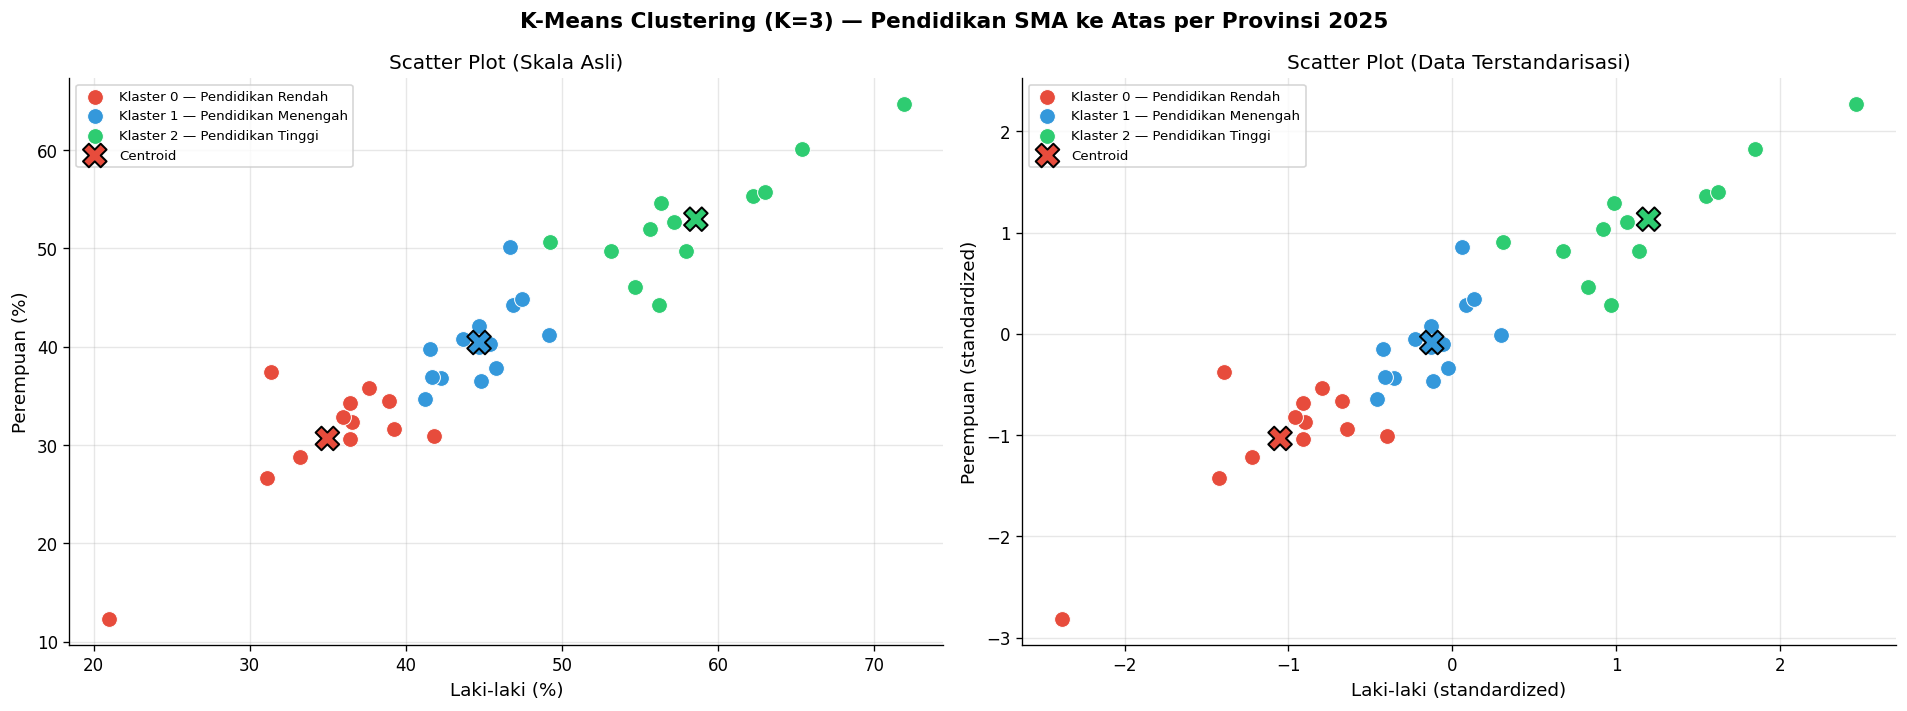

Gambar disimpan: scatter_clusters.png


In [ ]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12']
cmap   = colors[:OPTIMAL_K]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Clustering (K={OPTIMAL_K}) — Pendidikan SMA ke Atas per Provinsi 2025',
             fontsize=13, fontweight='bold')

# ── Scatter: skala asli ──
ax = axes[0]
for k in range(OPTIMAL_K):
    mask = df_prov['Klaster'] == k
    ax.scatter(df_prov.loc[mask, 'Laki_laki'], df_prov.loc[mask, 'Perempuan'],
               s=90, color=cmap[k], edgecolors='white', linewidths=0.6,
               label=label_map.get(k, f'Klaster {k}'), zorder=3)

# Centroid dalam skala asli
c_orig = scaler.inverse_transform(kmeans.cluster_centers_)
# Sesuaikan urutan centroid dengan rank_map
c_sorted = np.zeros_like(c_orig)
for old, new in rank_map.items():
    c_sorted[new] = c_orig[old]
ax.scatter(c_sorted[:, 0], c_sorted[:, 1], s=200, c=cmap,
           marker='X', edgecolors='black', linewidths=1.2, zorder=5, label='Centroid')

ax.set_xlabel('Laki-laki (%)', fontsize=11)
ax.set_ylabel('Perempuan (%)', fontsize=11)
ax.set_title('Scatter Plot (Skala Asli)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Scatter: skala terstandarisasi ──
ax2 = axes[1]
for k in range(OPTIMAL_K):
    mask = df_prov['Klaster'] == k
    ax2.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                s=90, color=cmap[k], edgecolors='white', linewidths=0.6,
                label=label_map.get(k, f'Klaster {k}'), zorder=3)

# Centroid terstandarisasi
c_std_sorted = np.zeros_like(kmeans.cluster_centers_)
for old, new in rank_map.items():
    c_std_sorted[new] = kmeans.cluster_centers_[old]
ax2.scatter(c_std_sorted[:, 0], c_std_sorted[:, 1], s=200, c=cmap,
            marker='X', edgecolors='black', linewidths=1.2, zorder=5, label='Centroid')

ax2.set_xlabel('Laki-laki (standardized)', fontsize=11)
ax2.set_ylabel('Perempuan (standardized)', fontsize=11)
ax2.set_title('Scatter Plot (Data Terstandarisasi)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_clusters.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan: scatter_clusters.png')

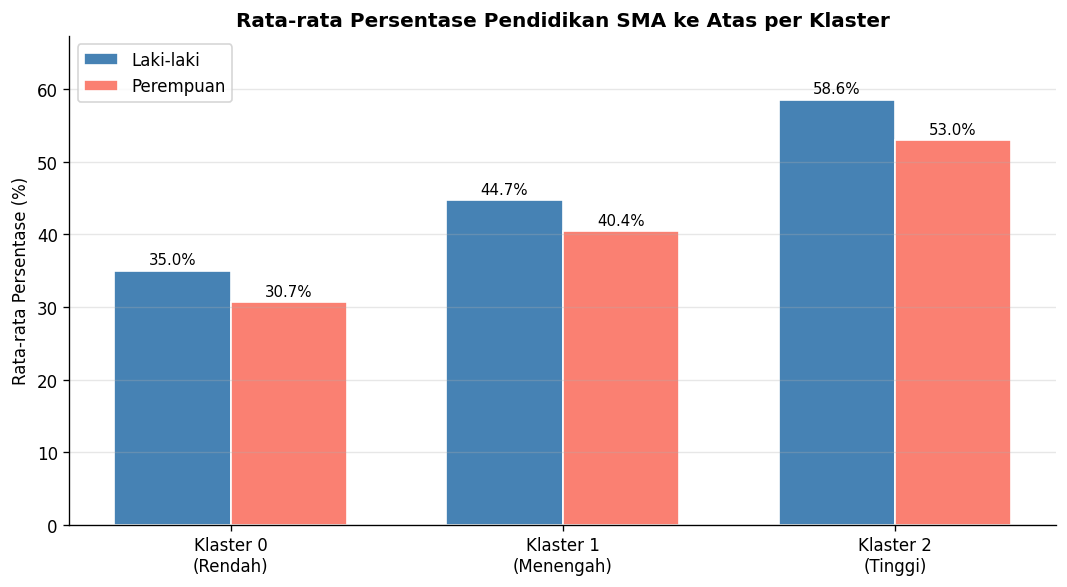

Gambar disimpan: barplot_clusters.png


In [ ]:
# Bar chart: rata-rata per klaster
cluster_avg = df_prov.groupby('Klaster')[features].mean().reset_index()
cluster_avg['Label'] = cluster_avg['Klaster'].map(
    {k: v.replace('Klaster \d+ — ', '') for k, v in label_map.items() if k < OPTIMAL_K}
)
# Buat label pendek
cluster_avg['LabelPendek'] = cluster_avg['Klaster'].apply(
    lambda k: ['Rendah','Menengah','Tinggi','Sangat Tinggi','Sangat Rendah'][k]
    if k < 5 else f'K{k}'
)

x = np.arange(OPTIMAL_K)
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, cluster_avg['Laki_laki'],  w, label='Laki-laki',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + w/2, cluster_avg['Perempuan'],   w, label='Perempuan',
               color='salmon',    edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Klaster {int(r)}\n({l})'
                    for r, l in zip(cluster_avg['Klaster'], cluster_avg['LabelPendek'])])
ax.set_ylabel('Rata-rata Persentase (%)')
ax.set_title('Rata-rata Persentase Pendidikan SMA ke Atas per Klaster', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(cluster_avg[features].max()) * 1.15)

plt.tight_layout()
plt.savefig('barplot_clusters.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan: barplot_clusters.png')

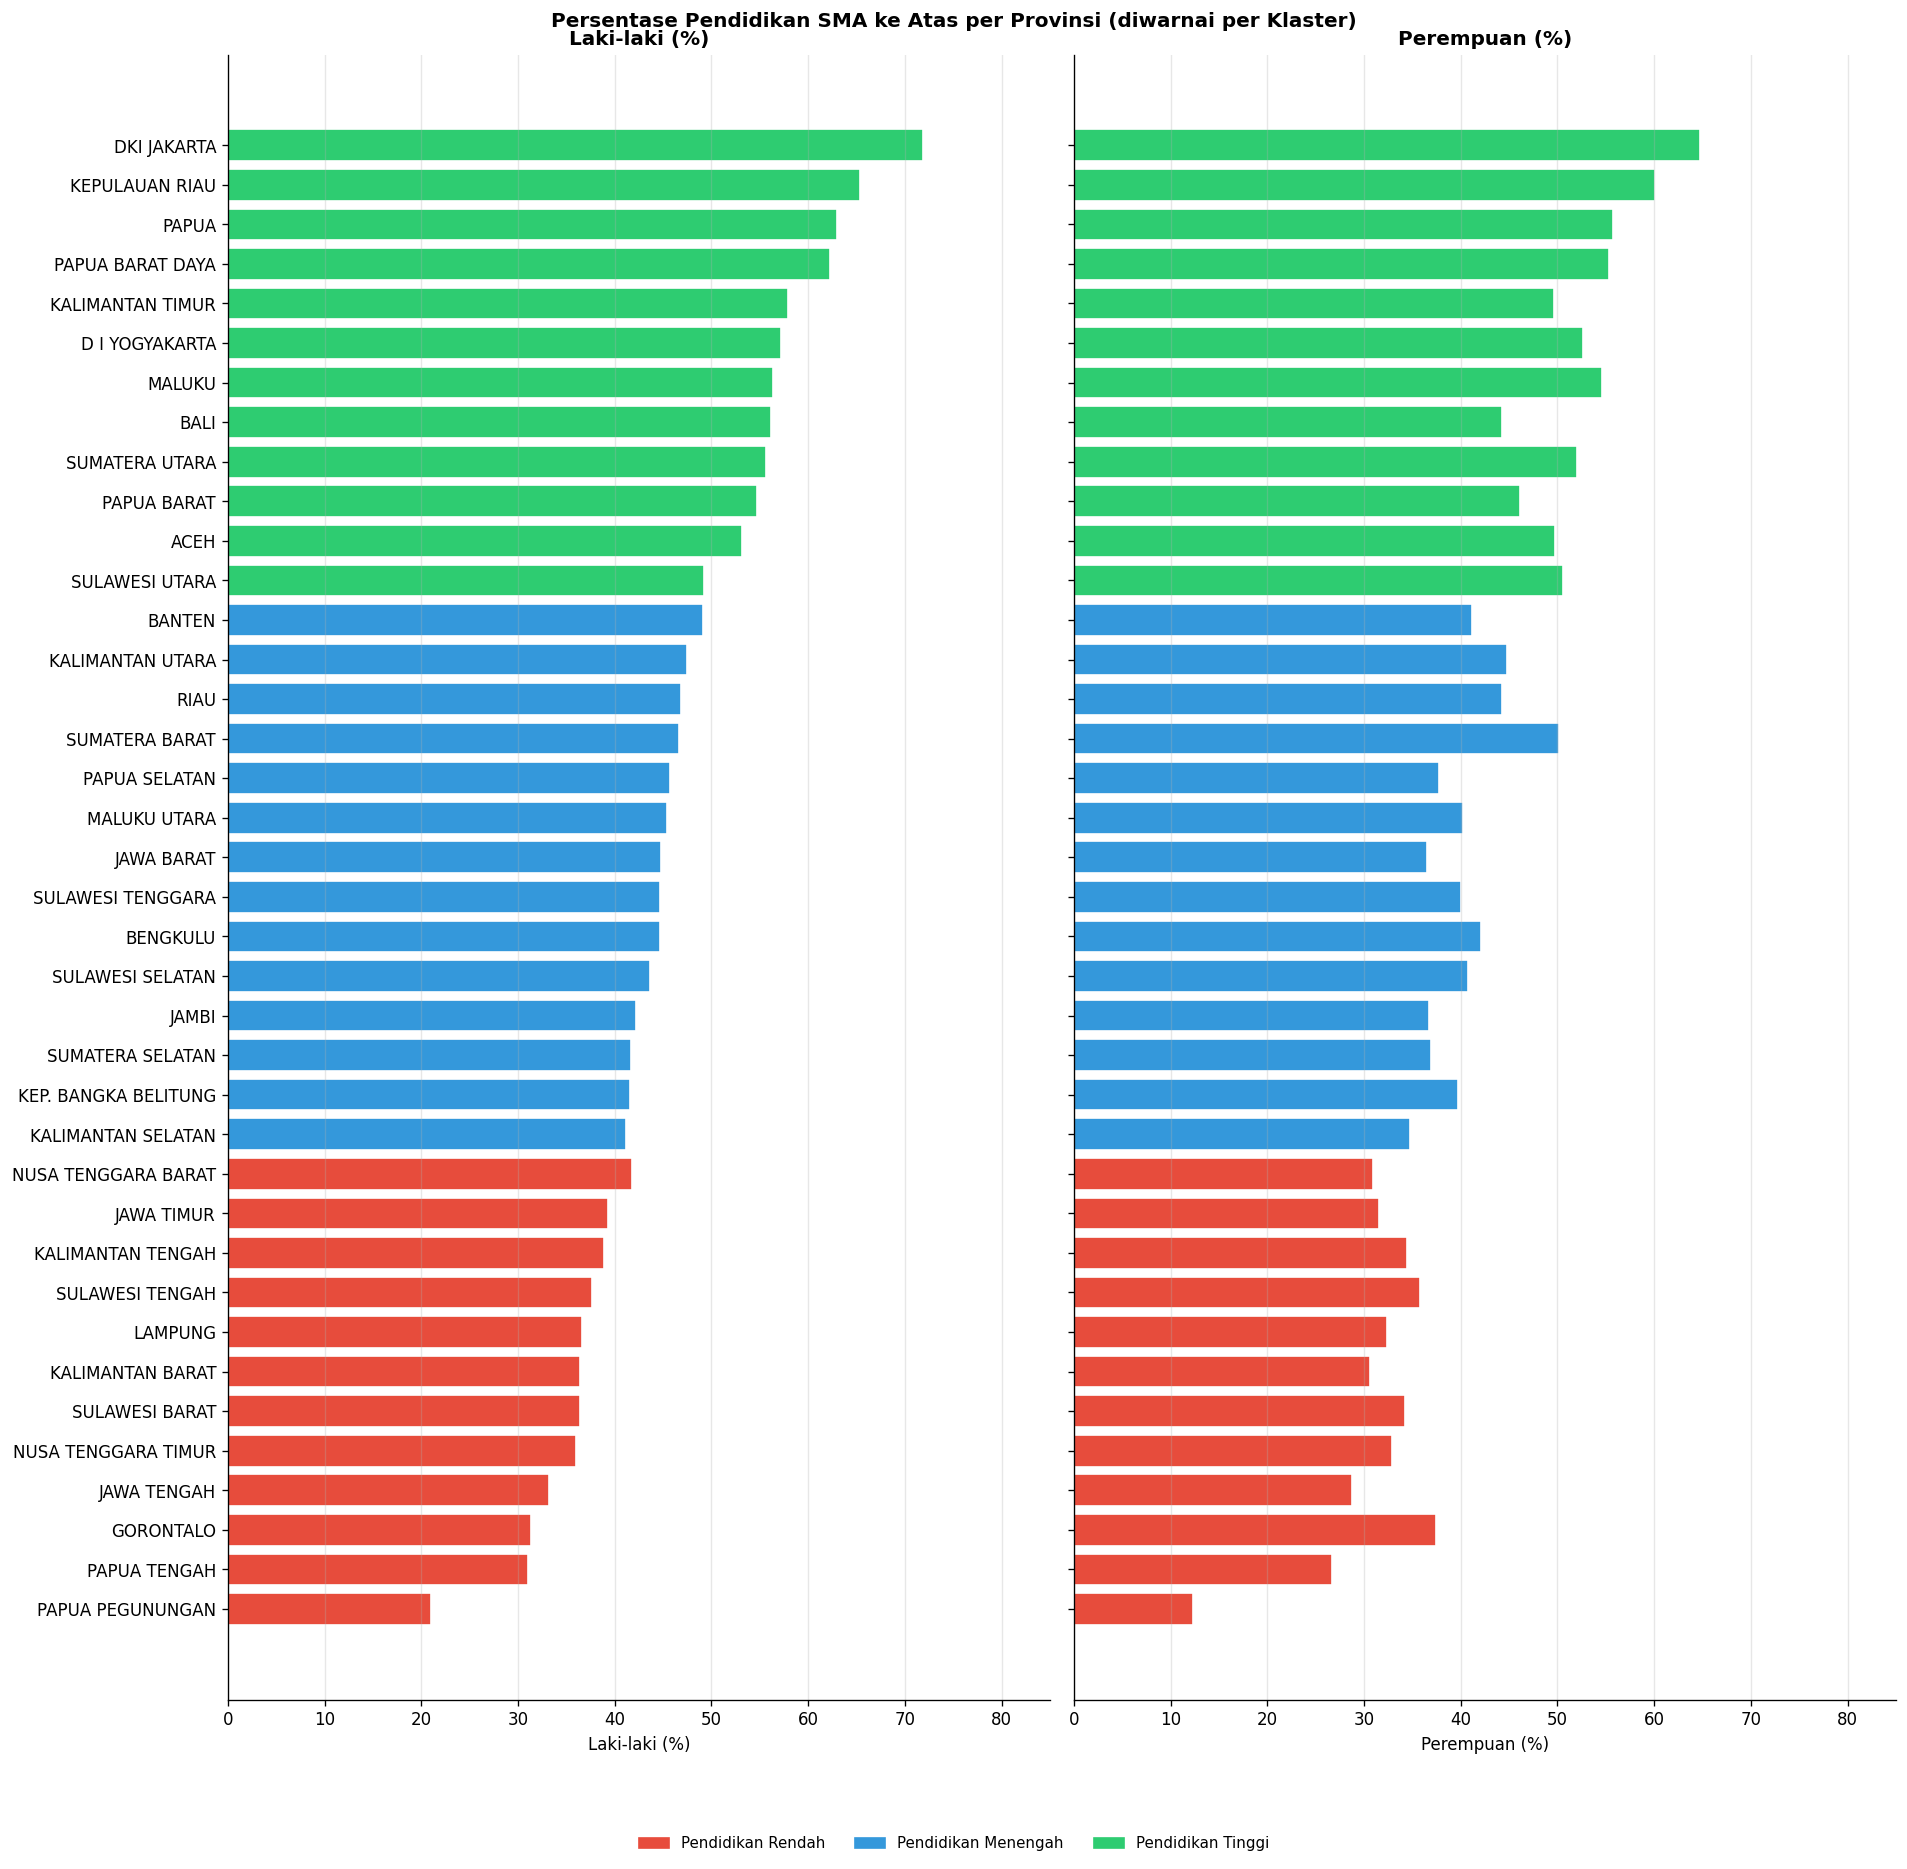

Gambar disimpan: hbar_provinsi.png


In [ ]:
# Horizontal bar: semua provinsi berwarna berdasarkan klaster
df_sorted = df_prov.sort_values(['Klaster', 'Laki_laki'])
bar_colors = [cmap[k] for k in df_sorted['Klaster']]

fig, axes = plt.subplots(1, 2, figsize=(16, len(df_sorted) * 0.38 + 1), sharey=True)
fig.suptitle('Persentase Pendidikan SMA ke Atas per Provinsi (diwarnai per Klaster)',
             fontsize=12, fontweight='bold')

for ax, col, title in zip(axes,
                           ['Laki_laki', 'Perempuan'],
                           ['Laki-laki (%)', 'Perempuan (%)']):
    ax.barh(df_sorted['Wilayah'], df_sorted[col], color=bar_colors, edgecolor='white', height=0.8)
    ax.set_xlabel(title)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 85)

# Legenda
patches = [mpatches.Patch(color=cmap[k],
           label=label_map.get(k, f'Klaster {k}').split(' — ')[-1])
           for k in range(OPTIMAL_K)]
fig.legend(handles=patches, loc='lower center', ncol=OPTIMAL_K,
           bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('hbar_provinsi.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan: hbar_provinsi.png')

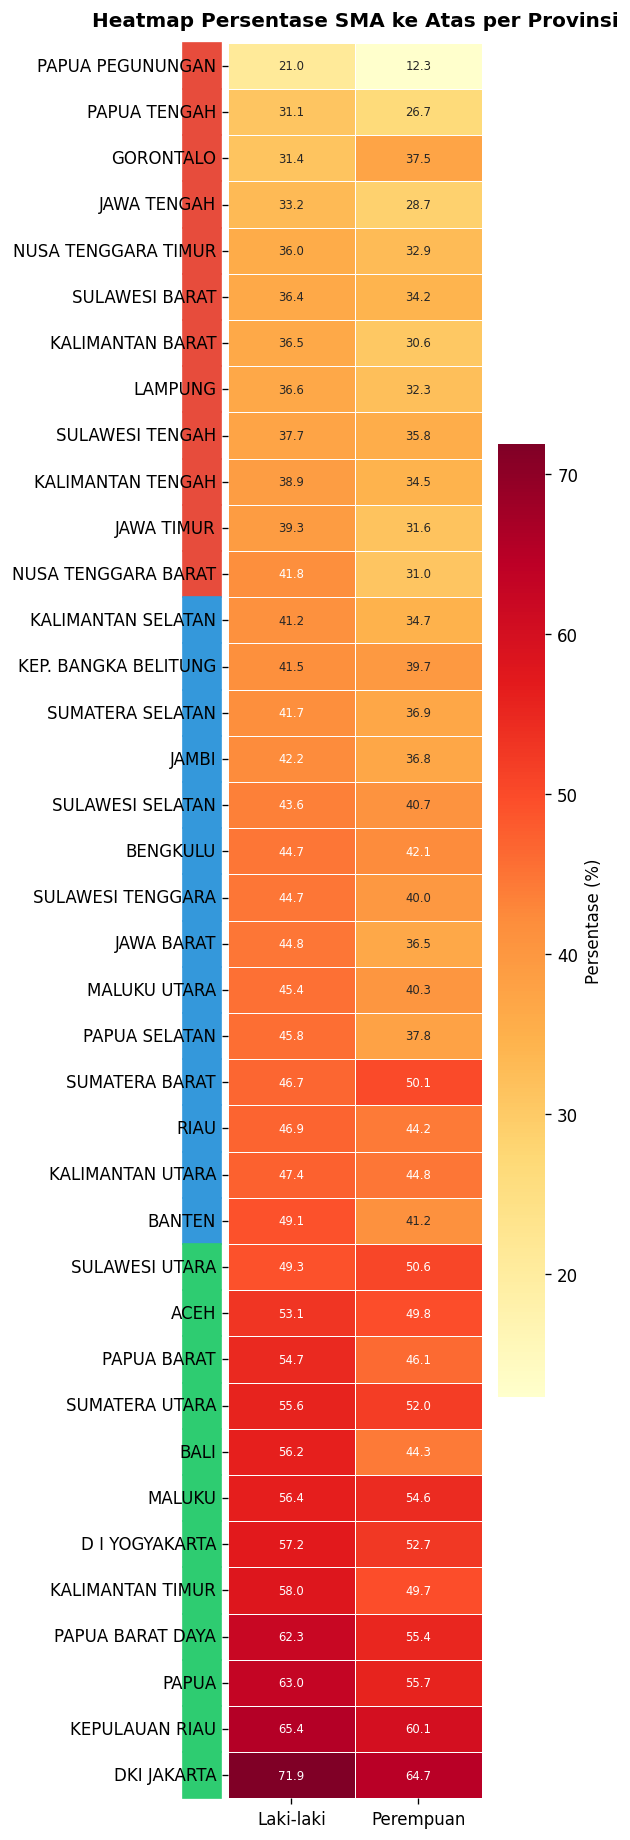

Gambar disimpan: heatmap_provinsi.png


In [ ]:
# Heatmap: semua provinsi × fitur, diurutkan per klaster
df_heat = df_sorted.set_index('Wilayah')[features].copy()
row_colors = [cmap[k] for k in df_sorted['Klaster']]

fig, ax = plt.subplots(figsize=(5, len(df_heat) * 0.38 + 1))
sns.heatmap(df_heat, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Persentase (%)', 'shrink': 0.6},
            ax=ax, annot_kws={'size': 7})

# Warna baris di kiri
for i, color in enumerate(row_colors):
    ax.add_patch(plt.Rectangle((-0.35, i), 0.3, 1,
                               color=color, clip_on=False, transform=ax.transData))

ax.set_title('Heatmap Persentase SMA ke Atas per Provinsi', fontweight='bold', pad=10)
ax.set_xticklabels(['Laki-laki', 'Perempuan'], rotation=0)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_provinsi.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan: heatmap_provinsi.png')

---
## 10. Simpan Hasil ke CSV

In [ ]:
output_file = 'hasil_clustering_SMA_2025.csv'
df_prov[['Wilayah', 'Laki_laki', 'Perempuan', 'Klaster', 'Label_Klaster']].to_csv(
    output_file, index=False, encoding='utf-8-sig'
)
print(f'✅ Hasil disimpan ke: {output_file}')

# Download otomatis jika di Google Colab
try:
    from google.colab import files
    files.download(output_file)
    print('⬇️  File sedang diunduh...')
except ImportError:
    print('ℹ️  Jalankan di Google Colab untuk unduh otomatis.')

✅ Hasil disimpan ke: hasil_clustering_SMA_2025.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  File sedang diunduh...


---
## 11. Ringkasan & Kesimpulan

In [ ]:
print('=' * 65)
print('           RINGKASAN HASIL K-MEANS CLUSTERING')
print('  Pendidikan SMA ke Atas Usia 25+ per Provinsi — 2025')
print('=' * 65)
print(f'  Jumlah provinsi yang dianalisis : {len(df_prov)}')
print(f'  Jumlah klaster (K)              : {OPTIMAL_K}')
print(f'  Silhouette Score                : {sil_final:.4f}')
print(f'  Davies-Bouldin Index            : {db_final:.4f}')
print(f'  Inertia (WCSS)                  : {inertia:.4f}')
print('=' * 65)

for k in range(OPTIMAL_K):
    g = df_prov[df_prov['Klaster'] == k]
    print(f"\n  {label_map.get(k, f'Klaster {k}')}  [{len(g)} provinsi]")
    print(f"    Laki-laki  : rata-rata {g['Laki_laki'].mean():.2f}%")
    print(f"    Perempuan  : rata-rata {g['Perempuan'].mean():.2f}%")
    names = ', '.join(g['Wilayah'].tolist())
    print(f"    Provinsi   : {names}")

print('\n' + '=' * 65)
print('INTERPRETASI UMUM:')
print('  • Provinsi di Klaster pendidikan TINGGI umumnya adalah')
print('    daerah perkotaan / Jawa / Pulau-pulau maju.')
print('  • Provinsi di Klaster pendidikan RENDAH cenderung berasal')
print('    dari wilayah terpencil / Papua / NTT / NTB.')
print('  • Kesenjangan Laki-laki vs Perempuan terlihat di beberapa')
print('    provinsi; perlu perhatian kebijakan gender-sensitif.')
print('=' * 65)

           RINGKASAN HASIL K-MEANS CLUSTERING
  Pendidikan SMA ke Atas Usia 25+ per Provinsi — 2025
  Jumlah provinsi yang dianalisis : 38
  Jumlah klaster (K)              : 3
  Silhouette Score                : 0.4434
  Davies-Bouldin Index            : 0.6625
  Inertia (WCSS)                  : 17.0497

  Klaster 0 — Pendidikan Rendah  [12 provinsi]
    Laki-laki  : rata-rata 34.98%
    Perempuan  : rata-rata 30.67%
    Provinsi   : LAMPUNG, JAWA TENGAH, JAWA TIMUR, NUSA TENGGARA BARAT, NUSA TENGGARA TIMUR, KALIMANTAN BARAT, KALIMANTAN TENGAH, SULAWESI TENGAH, GORONTALO, SULAWESI BARAT, PAPUA TENGAH, PAPUA PEGUNUNGAN

  Klaster 1 — Pendidikan Menengah  [14 provinsi]
    Laki-laki  : rata-rata 44.70%
    Perempuan  : rata-rata 40.42%
    Provinsi   : SUMATERA BARAT, RIAU, JAMBI, SUMATERA SELATAN, BENGKULU, KEP. BANGKA BELITUNG, JAWA BARAT, BANTEN, KALIMANTAN SELATAN, KALIMANTAN UTARA, SULAWESI SELATAN, SULAWESI TENGGARA, MALUKU UTARA, PAPUA SELATAN

  Klaster 2 — Pendidikan Tinggi  [